<a href="https://colab.research.google.com/github/ryyutku/Deep-RL-HuggingFace-course/blob/Unit-1/Unit_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 1: Train Deep Reinforcement Learning Agent 🤖

## Install dependencies and create a virtual screen 🔽

The first step is to install the dependencies, we’ll install multiple ones.

- `gymnasium[box2d]`: Contains the LunarLander-v2 environment 🌛
- `stable-baselines3[extra]`: The deep reinforcement learning library.
- `huggingface_sb3`: Additional code for Stable-baselines3 to load and upload models from the Hugging Face 🤗 Hub.

To make things easier, we created a script to install all these dependencies.

In [1]:
!apt install swig cmake

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.28.3-1build7).
Suggested packages:
  swig-doc swig-examples
The following NEW packages will be installed:
  swig
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 1,187 kB of archives.
After this operation, 5,672 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 swig amd64 4.2.0-2ubuntu1 [1,187 kB]
Fetched 1,187 kB in 1s (795 kB/s)
Selecting previously unselected package swig.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../swig_4.2.0-2ubuntu1_amd64.deb ...
Unpacking swig (4.2.0-2ubuntu1) ...
Setting up swig (4.2.0-2ubuntu1) ...
Processing triggers for man-db (2.12.0-4build2) ...


Download the python packages

In [2]:
!pip install "gymnasium[box2d]" "stable-baselines3[extra]" "huggingface_sb3" "pyvirtualdisplay"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
transforme

During the notebook, we'll need to generate a replay video. To do so, with colab, **we need to have a virtual screen to be able to render the environment** (and thus record the frames).

Hence the following cell will install virtual screen libraries and create and run a virtual screen 🖥

In [3]:
!sudo apt-get update
!sudo apt-get install -y python3-opengl ffmpeg xvfb

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Hit:7 http://archive.ubuntu.com/ubuntu noble InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,877 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:13 http://security.ubuntu.com/ubuntu noble-secur

In [4]:
# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

## Import the packages 📦

One additional library we import is huggingface_hub **to be able to upload and download trained models from the hub**.


The Hugging Face Hub 🤗 works as a central place where anyone can share and explore models and datasets. It has versioning, metrics, visualizations and other features that will allow you to easily collaborate with others.

You can see here all the Deep reinforcement Learning models available here👉 https://huggingface.co/models?pipeline_tag=reinforcement-learning&sort=downloads



In [5]:
import gymnasium as gym
from huggingface_sb3 import load_from_hub, package_to_hub
from huggingface_hub import notebook_login
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

print("All imports OK")

All imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
import gymnasium as gym
env = gym.make("LunarLander-v3")
obs, info = env.reset()
print("Observation shape:", env.observation_space.shape)
print("Action space:", env.action_space.n)
env.close()

Observation shape: (8,)
Action space: 4


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


## Understand Gymnasium and how it works 🤖

🏋 The library containing our environment is called Gymnasium.
**You'll use Gymnasium a lot in Deep Reinforcement Learning.**

Gymnasium is the **new version of Gym library** [maintained by the Farama Foundation](https://farama.org/).

The Gymnasium library provides two things:

- An interface that allows you to **create RL environments**.
- A **collection of environments** (gym-control, atari, box2D...).

Let's look at an example, but first let's recall the RL loop.

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit1/RL_process_game.jpg" alt="The RL process" width="100%">

At each step:
- Our Agent receives a **state (S0)** from the **Environment** — we receive the first frame of our game (Environment).
- Based on that **state (S0),** the Agent takes an **action (A0)** — our Agent will move to the right.
- The environment transitions to a **new** **state (S1)** — new frame.
- The environment gives some **reward (R1)** to the Agent — we’re not dead *(Positive Reward +1)*.


With Gymnasium:

1️⃣ We create our environment using `gymnasium.make()`

2️⃣ We reset the environment to its initial state with `observation = env.reset()`

At each step:

3️⃣ Get an action using our model (in our example we take a random action)

4️⃣ Using `env.step(action)`, we perform this action in the environment and get
- `observation`: The new state (st+1)
- `reward`: The reward we get after executing the action
- `terminated`: Indicates if the episode terminated (agent reach the terminal state)
- `truncated`: Introduced with this new version, it indicates a timelimit or if an agent go out of bounds of the environment for instance.
- `info`: A dictionary that provides additional information (depends on the environment).

For more explanations check this 👉 https://gymnasium.farama.org/api/env/#gymnasium.Env.step

If the episode is terminated:
- We reset the environment to its initial state with `observation = env.reset()`

**Let's look at an example!** Make sure to read the code


In [7]:
import gymnasium as gym

# Create our environment called LunarLander-v3
env = gym.make("LunarLander-v3")

# Then reset this environment
observation, info = env.reset()

for _ in range(20):
  # Take a random action
  action = env.action_space.sample()
  print("Action taken:", action)



  # Do this action in the environment and get
  # next_state, reward, terminated, truncated and info
  observation, reward, terminated, truncated, info = env.step(action)

  # If the game is terminated (in our case we land, crashed) or truncated (timeout)
  if terminated or truncated:
    # Reset the environment
    print("Environment is reset")
    observation, info = env.reset()

env.close()

Action taken: 0
Action taken: 1
Action taken: 3
Action taken: 2
Action taken: 1
Action taken: 1
Action taken: 3
Action taken: 1
Action taken: 0
Action taken: 0
Action taken: 3
Action taken: 3
Action taken: 2
Action taken: 2
Action taken: 0
Action taken: 1
Action taken: 0
Action taken: 2
Action taken: 3
Action taken: 1


## Create the LunarLander environment 🌛 and understand how it works

### [The environment 🎮](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

In this first tutorial, we’re going to train our agent, a [Lunar Lander](https://gymnasium.farama.org/environments/box2d/lunar_lander/), **to land correctly on the moon**. To do that, the agent needs to learn **to adapt its speed and position (horizontal, vertical, and angular) to land correctly.**

---


💡 A good habit when you start to use an environment is to check its documentation

👉 https://gymnasium.farama.org/environments/box2d/lunar_lander/

---


In [8]:
# Create environment with gym.make("<name of the environment>")
env = gym.make("LunarLander-v3")
env.reset()
print("_____OBSERVATION SPACE_____\n")
print("Observation Space Shape", env.observation_space.shape)
print("Sample observation", env.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____

Observation Space Shape (8,)
Sample observation [ 2.2200809   1.3197103  -0.1688724  -8.917293    6.031518    9.949395
  0.06782581  0.9629742 ]


We see with `Observation Space Shape (8,)` that the observation is a vector of size 8, where each value contains different information about the lander:
- Horizontal pad coordinate (x)
- Vertical pad coordinate (y)
- Horizontal speed (x)
- Vertical speed (y)
- Angle
- Angular speed
- If the left leg contact point has touched the land (boolean)
- If the right leg contact point has touched the land (boolean)


In [ ]:
print("\n _____ACTION SPACE_____\n")
print("Action Space Shape", env.action_space.n)
print("Action Space Shape", env.action_space.sample()) # Take a random action


 _____ACTION SPACE_____

Action Space Shape 4
Action Space Shape 0


The action space (the set of possible actions the agent can take) is discrete with 4 actions available 🎮:

- Action 0: Do nothing,
- Action 1: Fire left orientation engine,
- Action 2: Fire the main engine,
- Action 3: Fire right orientation engine.

Reward function (the function that will give a reward at each timestep) 💰:

After every step a reward is granted. The total reward of an episode is the **sum of the rewards for all the steps within that episode**.

For each step, the reward:

- Is increased/decreased the closer/further the lander is to the landing pad.
-  Is increased/decreased the slower/faster the lander is moving.
- Is decreased the more the lander is tilted (angle not horizontal).
- Is increased by 10 points for each leg that is in contact with the ground.
- Is decreased by 0.03 points each frame a side engine is firing.
- Is decreased by 0.3 points each frame the main engine is firing.

The episode receive an **additional reward of -100 or +100 points for crashing or landing safely respectively.**

An episode is **considered a solution if it scores at least 200 points.**

#### Vectorized Environment

- We create a vectorized environment (a method for stacking multiple independent environments into a single environment) of 16 environments, this way, **we'll have more diverse experiences during the training.**

In [9]:
# Create the environment
env = make_vec_env("LunarLander-v3", n_envs=16)

## Create the Model 🤖
- We have studied our environment and we understood the problem: **being able to land the Lunar Lander to the Landing Pad correctly by controlling left, right and main orientation engine**. Now let's build the algorithm we're going to use to solve this Problem 🚀.

- To do so, we're going to use our first Deep RL library, [Stable Baselines3 (SB3)](https://stable-baselines3.readthedocs.io/en/master/).

- SB3 is a set of **reliable implementations of reinforcement learning algorithms in PyTorch**.

---

💡 A good habit when using a new library is to dive first on the documentation: https://stable-baselines3.readthedocs.io/en/master/ and then try some tutorials.

----

To solve this problem, we're going to use SB3 **PPO**. [PPO (aka Proximal Policy Optimization) is one of the SOTA (state of the art) Deep Reinforcement Learning algorithms that you'll study during this course](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html#example%5D).

PPO is a combination of:
- *Value-based reinforcement learning method*: learning an action-value function that will tell us the **most valuable action to take given a state and action**.
- *Policy-based reinforcement learning method*: learning a policy that will **give us a probability distribution over actions**.

Stable-Baselines3 is easy to set up:

1️⃣ You **create your environment** (in our case it was done above)

2️⃣ You define the **model you want to use and instantiate this model** `model = PPO("MlpPolicy")`

3️⃣ You **train the agent** with `model.learn` and define the number of training timesteps

```
# Create environment
env = gym.make('LunarLander-v2')

# Instantiate the agent
model = PPO('MlpPolicy', env, verbose=1)
# Train the agent
model.learn(total_timesteps=int(2e5))
```



In [10]:
# Defining the PPO MlpPolicy architecture
# We use MultiLayerPerceptron (MLPPolicy) because the inpupt is a vector,
# if we had frames as input we would use CnnPolicy
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    n_steps = 1024,
    batch_size = 64,
    n_epochs = 4,
    gamma = 0.999,
    gae_lambda = 0.98,
    ent_coef = 0.01,
    )


Using cuda device


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Train the PPO agent 🏃
- Let's train our agent for 1,000,000 timesteps, don't forget to use GPU on Colab. It will take approximately ~20min, but you can use fewer timesteps if you just want to try it out.
- During the training, take a ☕ break you deserved it 🤗

In [ ]:
# Train it for 1,000,000 timesteps
model.learn(total_timesteps=1000000)

# Save the model to file
model_name = "ppo-LunarLander-v3"
model.save(model_name)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 90.9     |
|    ep_rew_mean     | -193     |
| time/              |          |
|    fps             | 2709     |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90.1        |
|    ep_rew_mean          | -152        |
| time/                   |             |
|    fps                  | 2219        |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.007927874 |
|    clip_fraction        | 0.0734      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.000428   |
|    learning_rate        | 0.

## Evaluate the agent 📈
- Remember to wrap the environment in a [Monitor](https://stable-baselines3.readthedocs.io/en/master/common/monitor.html).
- Now that our Lunar Lander agent is trained 🚀, we need to **check its performance**.
- Stable-Baselines3 provides a method to do that: `evaluate_policy`.
- To fill that part you need to [check the documentation](https://stable-baselines3.readthedocs.io/en/master/guide/examples.html#basic-usage-training-saving-loading)
- In the next step,  we'll see **how to automatically evaluate and share your agent to compete in a leaderboard, but for now let's do it ourselves**


💡 When you evaluate your agent, you should not use your training environment but create an evaluation environment.

In [13]:
from stable_baselines3 import DQN
# TODO: Evaluate the agent
# Create a new environment for evaluation
eval_env = Monitor(gym.make("LunarLander-v3", render_mode='rgb_array'))
# Load the PPO model (SB3 auto-appends .zip)
model = PPO.load("LunarLander-v3", env=eval_env)

# Evaluate the model with 10 evaluation episodes and deterministic=True
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)

# Print the results
print(f"mean_reward= {mean_reward:.2f} +/- {std_reward:.2f}")



Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


mean_reward= 227.15 +/- 15.54


By using `package_to_hub` **you evaluate, record a replay, generate a model card of your agent and push it to the hub**.

This way:
- You can **showcase our work** 🔥
- You can **visualize your agent playing** 👀
- You can **share with the community an agent that others can use** 💾
- You can **access a leaderboard 🏆 to see how well your agent is performing compared to your classmates** 👉 https://huggingface.co/spaces/huggingface-projects/Deep-Reinforcement-Learning-Leaderboard


In [14]:
notebook_login()
!git config --global credential.helper store

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Let's fill the `package_to_hub` function:
- `model`: our trained model.
- `model_name`: the name of the trained model that we defined in `model_save`
- `model_architecture`: the model architecture we used, in our case PPO
- `env_id`: the name of the environment, in our case `LunarLander-v2`
- `eval_env`: the evaluation environment defined in eval_env
- `repo_id`: the name of the Hugging Face Hub Repository that will be created/updated `(repo_id = {username}/{repo_name})`

💡 **A good name is {username}/{model_architecture}-{env_id}**

- `commit_message`: message of the commit

In [17]:
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.env_util import make_vec_env

from huggingface_sb3 import package_to_hub

# PLACE the variables you've just defined two cells above
# Define the name of the environment
env_id = "LunarLander-v3"

# TODO: Define the model architecture we used
model_architecture = "PPO"

## Define a repo_id
## repo_id is the id of the model repository from the Hugging Face Hub (repo_id = {organization}/{repo_name} for instance ThomasSimonini/ppo-LunarLander-v2
## CHANGE WITH YOUR REPO ID
repo_id = "ryyutku/ppo-LunarLander-v3" # Change with your repo id, you can't push with mine 😄

## Define the commit message
commit_message = "Upload PPO LunarLander-v3 trained agent"

# Create the evaluation env and set the render_mode="rgb_array"
eval_env = DummyVecEnv([lambda: gym.make(env_id, render_mode="rgb_array")])

# PLACE the package_to_hub function you've just filled here
package_to_hub(model=model, # Our trained model
               model_name="ppo-LunarLander-v3", # The name of our trained model
               model_architecture=model_architecture, # The model architecture we used: in our case PPO
               env_id=env_id, # Name of the environment
               eval_env=eval_env, # Evaluation Environment
               repo_id=repo_id, # id of the model repository from the Hugging Face Hub (repo_id = {organization}/{repo_name} for instance ThomasSimonini/ppo-LunarLander-v2
               commit_message=commit_message)


ℹ This function will save, evaluate, generate a video of your agent,
create a model card and push everything to the hub. It might take up to 1min.
This is a work in progress: if you encounter a bug, please open an issue.


/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Saving video to /tmp/tmp2rhtkqs9/-step-0-to-step-1000.mp4
Moviepy - Building video /tmp/tmp2rhtkqs9/-step-0-to-step-1000.mp4.
Moviepy - Writing video /tmp/tmp2rhtkqs9/-step-0-to-step-1000.mp4



Moviepy - Done !
Moviepy - video ready /tmp/tmp2rhtkqs9/-step-0-to-step-1000.mp4
✘ 'DummyVecEnv' object has no attribute 'video_recorder'
✘ We are unable to generate a replay of your agent, the package_to_hub
process continues
✘ Please open an issue at
https://github.com/huggingface/huggingface_sb3/issues
ℹ Pushing repo ryyutku/ppo-LunarLander-v3 to the Hugging Face Hub


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

  ...-v3/pytorch_variables.pth: 100%|##########| 1.26kB / 1.26kB            

  ...LunarLander-v3/policy.pth: 100%|##########| 44.1kB / 44.1kB            

  ...r-v3/policy.optimizer.pth: 100%|##########| 88.9kB / 88.9kB            

ℹ Your model is pushed to the Hub. You can view your model here:
https://huggingface.co/ryyutku/ppo-LunarLander-v3/tree/main/


CommitInfo(commit_url='https://huggingface.co/ryyutku/ppo-LunarLander-v3/commit/8fd345486d43577749e668a598f2efad31cab062', commit_message='Upload PPO LunarLander-v3 trained agent', commit_description='', oid='8fd345486d43577749e668a598f2efad31cab062', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ryyutku/ppo-LunarLander-v3', endpoint='https://huggingface.co', repo_type='model', repo_id='ryyutku/ppo-LunarLander-v3'), pr_revision=None, pr_num=None)

Congrats 🥳 you've just trained and uploaded your first Deep Reinforcement Learning agent. The script above should have displayed a link to a model repository such as https://huggingface.co/osanseviero/test_sb3. When you go to this link, you can:
* See a video preview of your agent at the right.
* Click "Files and versions" to see all the files in the repository.
* Click "Use in stable-baselines3" to get a code snippet that shows how to load the model.
* A model card (`README.md` file) which gives a description of the model

Under the hood, the Hub uses git-based repositories (don't worry if you don't know what git is), which means you can update the model with new versions as you experiment and improve your agent.

Compare the results of your LunarLander-v2 with your classmates using the leaderboard 🏆 👉 https://huggingface.co/spaces/huggingface-projects/Deep-Reinforcement-Learning-Leaderboard

In [18]:
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv
import gymnasium as gym

# Wrap env in DummyVecEnv + VideoRecorder
video_env = DummyVecEnv([lambda: gym.make("LunarLander-v3", render_mode="rgb_array")])
video_env = VecVideoRecorder(
    video_env,
    video_folder="./videos",
    record_video_trigger=lambda step: step == 0,   # record from step 0
    video_length=1000,                              # ~one full episode
    name_prefix="ppo-lunarlander",
)

# Run one episode
obs = video_env.reset()
for _ in range(1000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = video_env.step(action)
    if done:
        break

video_env.close()
print("Done — check the ./videos folder")

Saving video to /content/videos/ppo-lunarlander-step-0-to-step-1000.mp4
Moviepy - Building video /content/videos/ppo-lunarlander-step-0-to-step-1000.mp4.
Moviepy - Writing video /content/videos/ppo-lunarlander-step-0-to-step-1000.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/ppo-lunarlander-step-0-to-step-1000.mp4
Done — check the ./videos folder


In [19]:
from IPython.display import Video
import glob

video_path = glob.glob("./videos/*.mp4")[0]
Video(video_path, embed=True, width=640)

See the playback run live

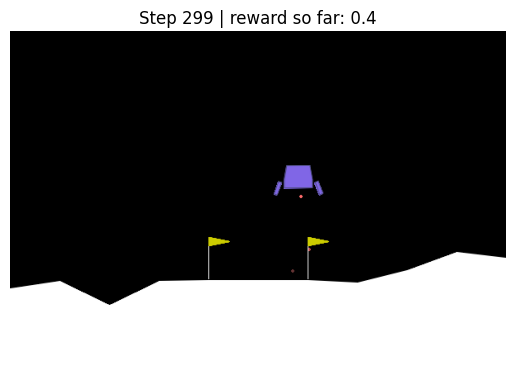

In [20]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import gymnasium as gym

env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset()

for i in range(300):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Step {i} | reward so far: {reward:.1f}")
    plt.show()

    if terminated or truncated:
        obs, info = env.reset()

env.close()